# Notebook "Tutorial de Proyecto de Regresión Lineal"

In [1]:
from utils import db_connect
engine = db_connect()
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

#Imported Necessary Libraries // Librerias necesarias para el proyecto. 

In [2]:
# Load Database / Cargar base de datos.
df = pd.read_csv('/workspaces/Tutorial-de-Proyecto-de-Regresi-n-Linea/data/raw/medical_insurance_cost.csv')
total_data = df 
total_data.head()



,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
# Database features / Características de la base de datos
print(total_data.shape)
print(total_data.describe())
print(total_data.info())

#In this case we took "charges" as the study main variable / Se toma en este caso "charges" como la variable principal de estudio.
#We got 4 numerical variables (age,bmi,children,charges) and 3 categorical (sex, smoker, region) / Tenemos 4 variables numéricas (age,bmi,children,charges)
# y 3 categoricas (sex, smoker, region).

(1338, 7)
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float

In [4]:
#Eliminate duplicates / Eliminar duplicados. 
total_data[total_data.duplicated(keep=False)]
total_data = total_data.drop_duplicates()
total_data.shape

(1337, 7)

In [5]:
#Check for null values / Verificar valores nulos.
total_data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [6]:
#Determinate irrelevant features / Determinar características irrelevantes.
#In this case we don't have any irrelevant feature / En este caso no tenemos ninguna característica irrelevante.

#### Analysis on categorical variables / Analisis en variables categoricas

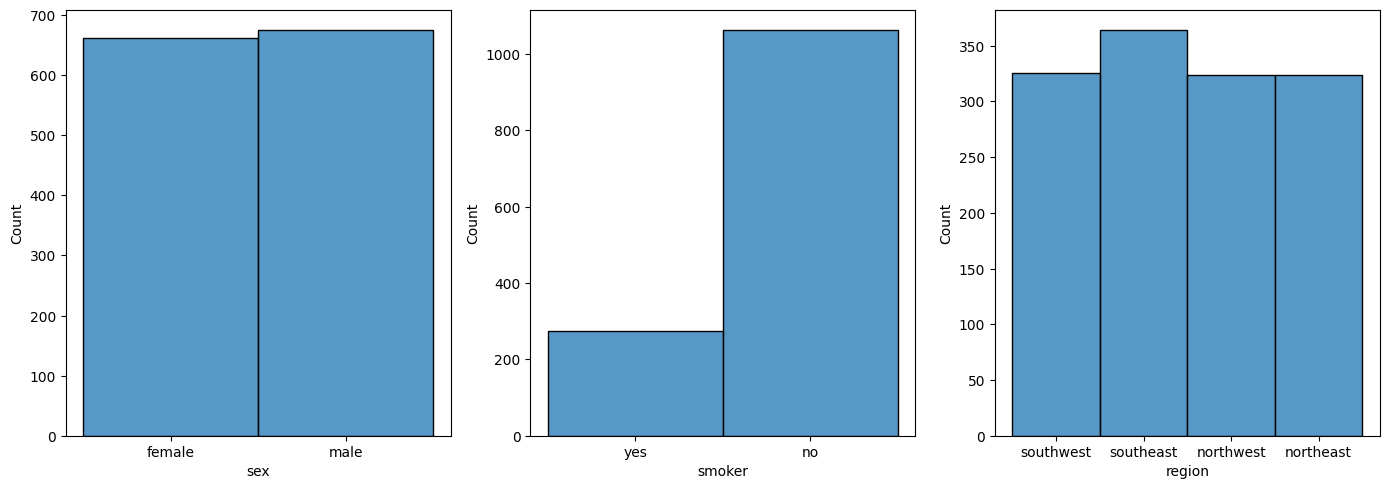

In [ ]:
fig, axis = plt.subplots(1, 3, figsize=(14, 5))

# Create Histogram / Crear histogramas
sns.histplot(ax = axis[0], data = total_data, x = "sex")
sns.histplot(ax = axis[1], data = total_data, x = "smoker")
sns.histplot(ax = axis[2], data = total_data, x = "region")

# Adjust layout / Ajustar el diseño
plt.tight_layout()

# Show the plot / Mostrar el gráfico
plt.show()

#### Analysis on numeric variables / Analisis en variavles numericas

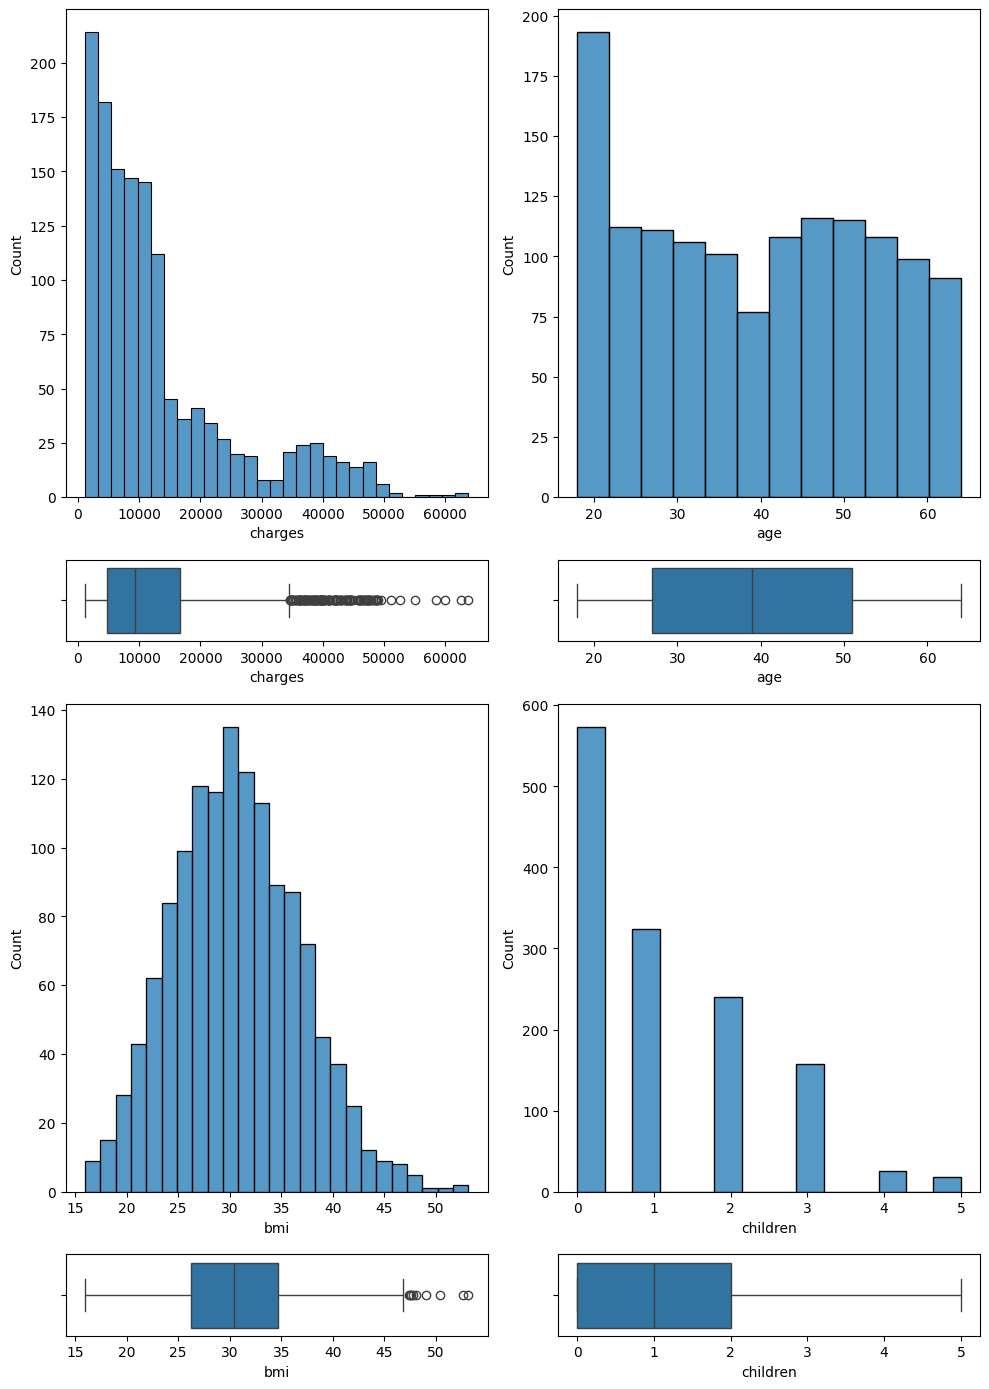

In [ ]:
fig, axis = plt.subplots(4, 2, figsize = (10, 14), gridspec_kw = {"height_ratios": [6, 1, 6, 1]})

sns.histplot(ax = axis[0, 0], data = total_data, x = "charges")
sns.boxplot(ax = axis[1, 0], data = total_data, x = "charges")

sns.histplot(ax = axis[0, 1], data = total_data, x = "age")
sns.boxplot(ax = axis[1, 1], data = total_data, x = "age")

sns.histplot(ax = axis[2, 0], data = total_data, x = "bmi")
sns.boxplot(ax = axis[3, 0], data = total_data, x = "bmi")

sns.histplot(ax = axis[2, 1], data = total_data, x = "children")
sns.boxplot(ax = axis[3, 1], data = total_data, x = "children")

# Adjust layout / Ajustar el diseño
plt.tight_layout()

# Show the plot / Mostrar el gráfico
plt.show()

#### Numerical-numerical analysis / Analisis numerico-numerico

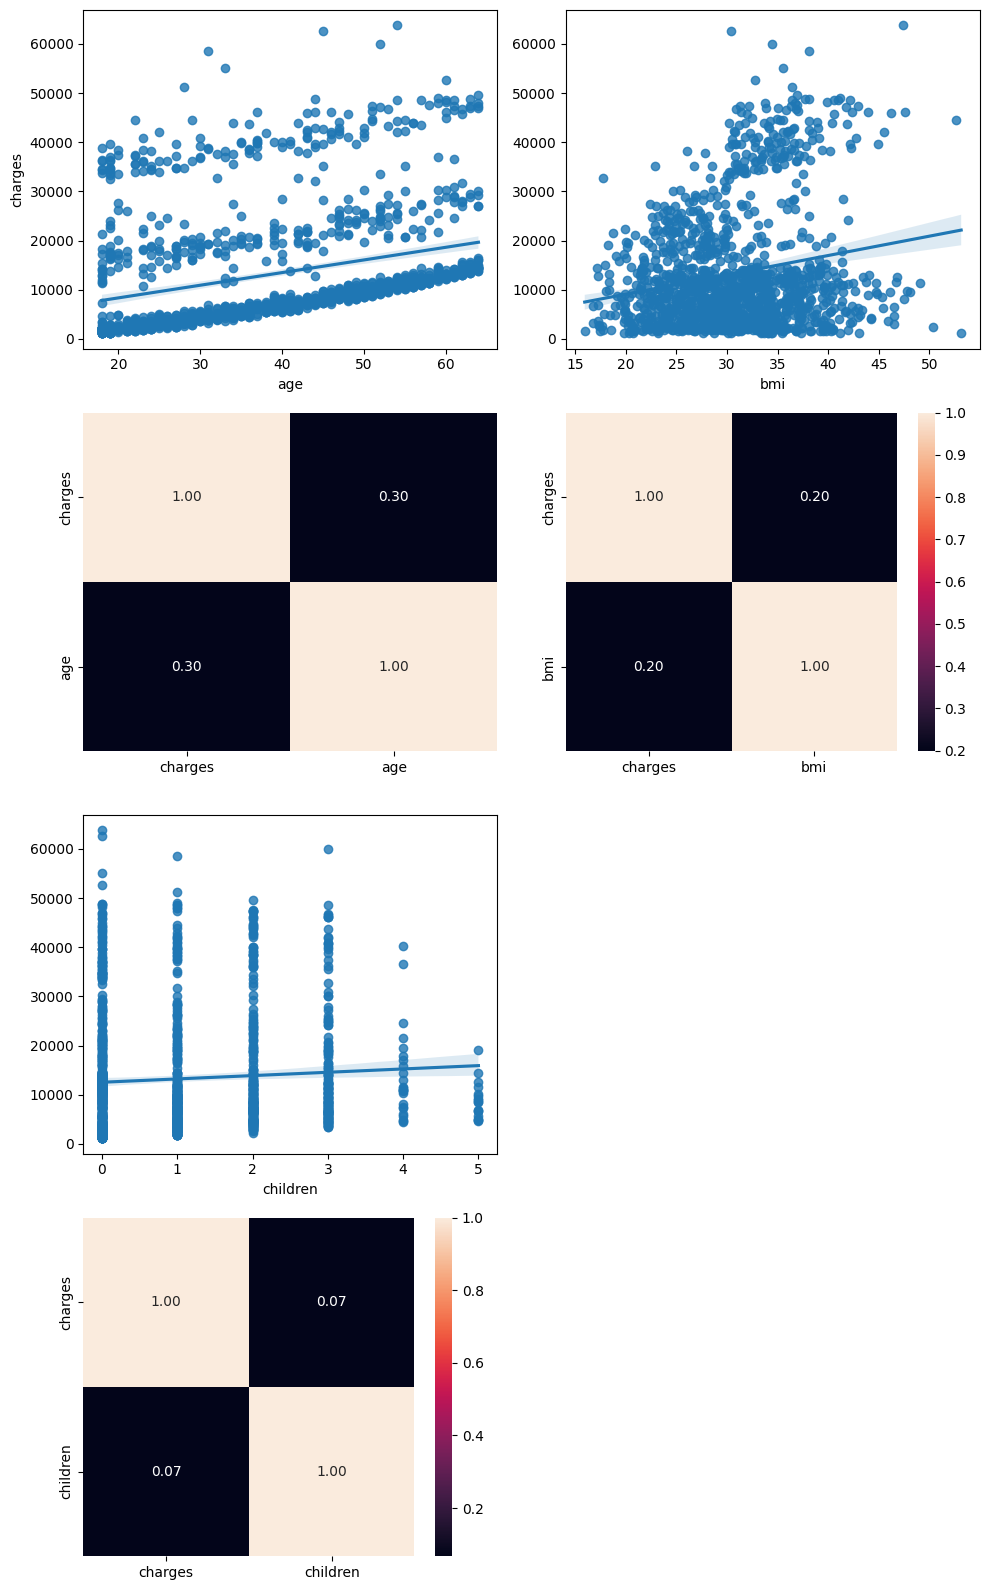

In [ ]:
# Numerical - Numerical Analysis / Análisis numérico - numérico

# Create subplot canvas / Crear lienzo de subgráficos
fig, axis = plt.subplots(4, 2, figsize = (10, 16))

# Create Plates / Crear gráficos
sns.regplot(ax = axis[0, 0], data = total_data, x = "age", y = "charges")
sns.heatmap(total_data[["charges", "age"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 0], cbar = False)

sns.regplot(ax = axis[0, 1], data = total_data, x = "bmi", y = "charges").set(ylabel = None)
sns.heatmap(total_data[["charges", "bmi"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 1])

sns.regplot(ax = axis[2, 0], data = total_data, x = "children", y = "charges").set(ylabel = None)
sns.heatmap(total_data[["charges", "children"]].corr(), annot = True, fmt = ".2f", ax = axis[3, 0]).set(ylabel = None)
fig.delaxes(axis[2, 1])
fig.delaxes(axis[3, 1])

# Adjust layout / Ajustar el diseño
plt.tight_layout()

# Show the plot / Mostrar el gráfico
plt.show()

#### Categorical-categorical analysis / Analisis categorico-categorico

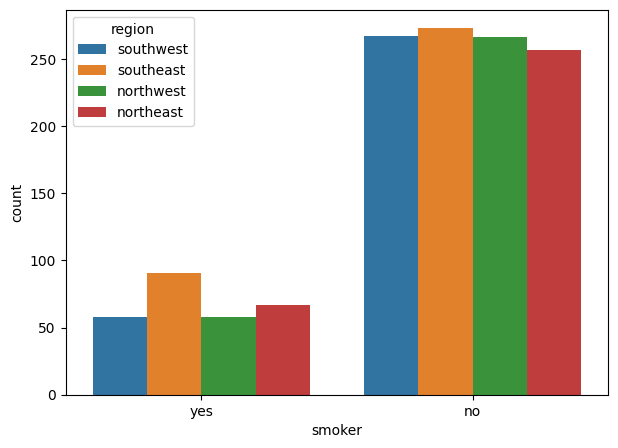

In [ ]:
fig, axis = plt.subplots(figsize = (7, 5))

sns.countplot(data = total_data, x = "smoker", hue = "region")

# Show the plot / Mostrar el gráfico
plt.show()

#### Numerical-categorical analysis (complete) / Analisis numerico-categorico (completo)

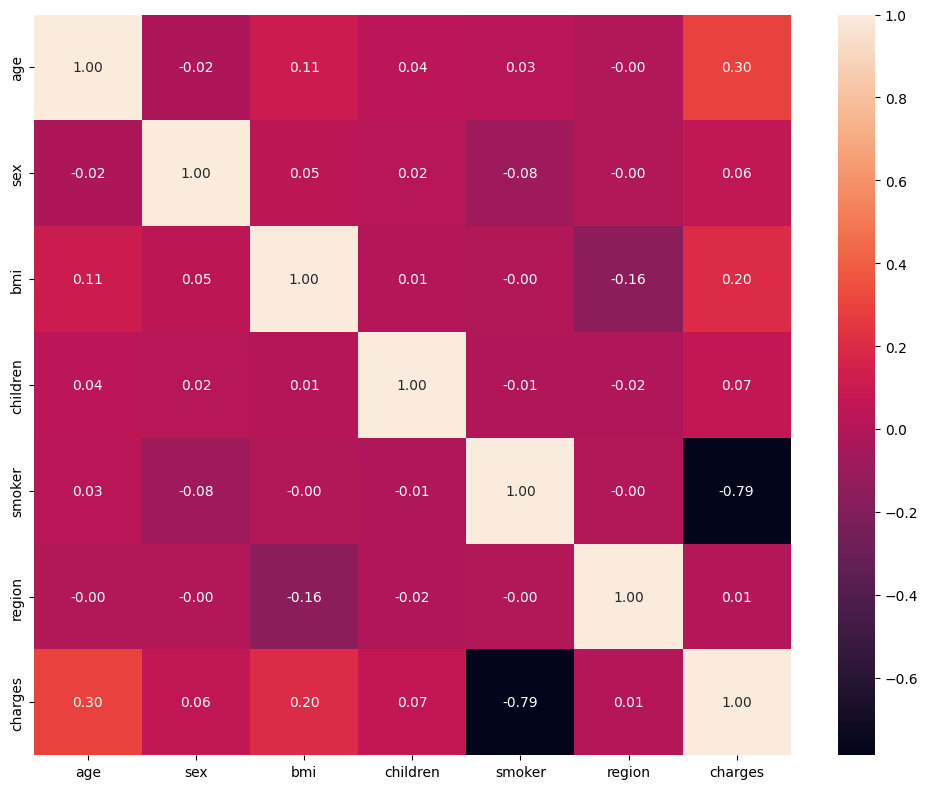

In [11]:
# Factorize the categorical variables
total_data["sex"] = pd.factorize(total_data["sex"])[0]
total_data["smoker"] = pd.factorize(total_data["smoker"])[0]
total_data["region"] = pd.factorize(total_data["region"])[0]

fig, axes = plt.subplots(figsize=(10, 8))

sns.heatmap(total_data[["age", "sex", "bmi", "children", "smoker", "region", "charges"]].corr(), annot = True, fmt = ".2f")

plt.tight_layout()

# Draw Plot
plt.show()

#### Analysing all the Data at Once

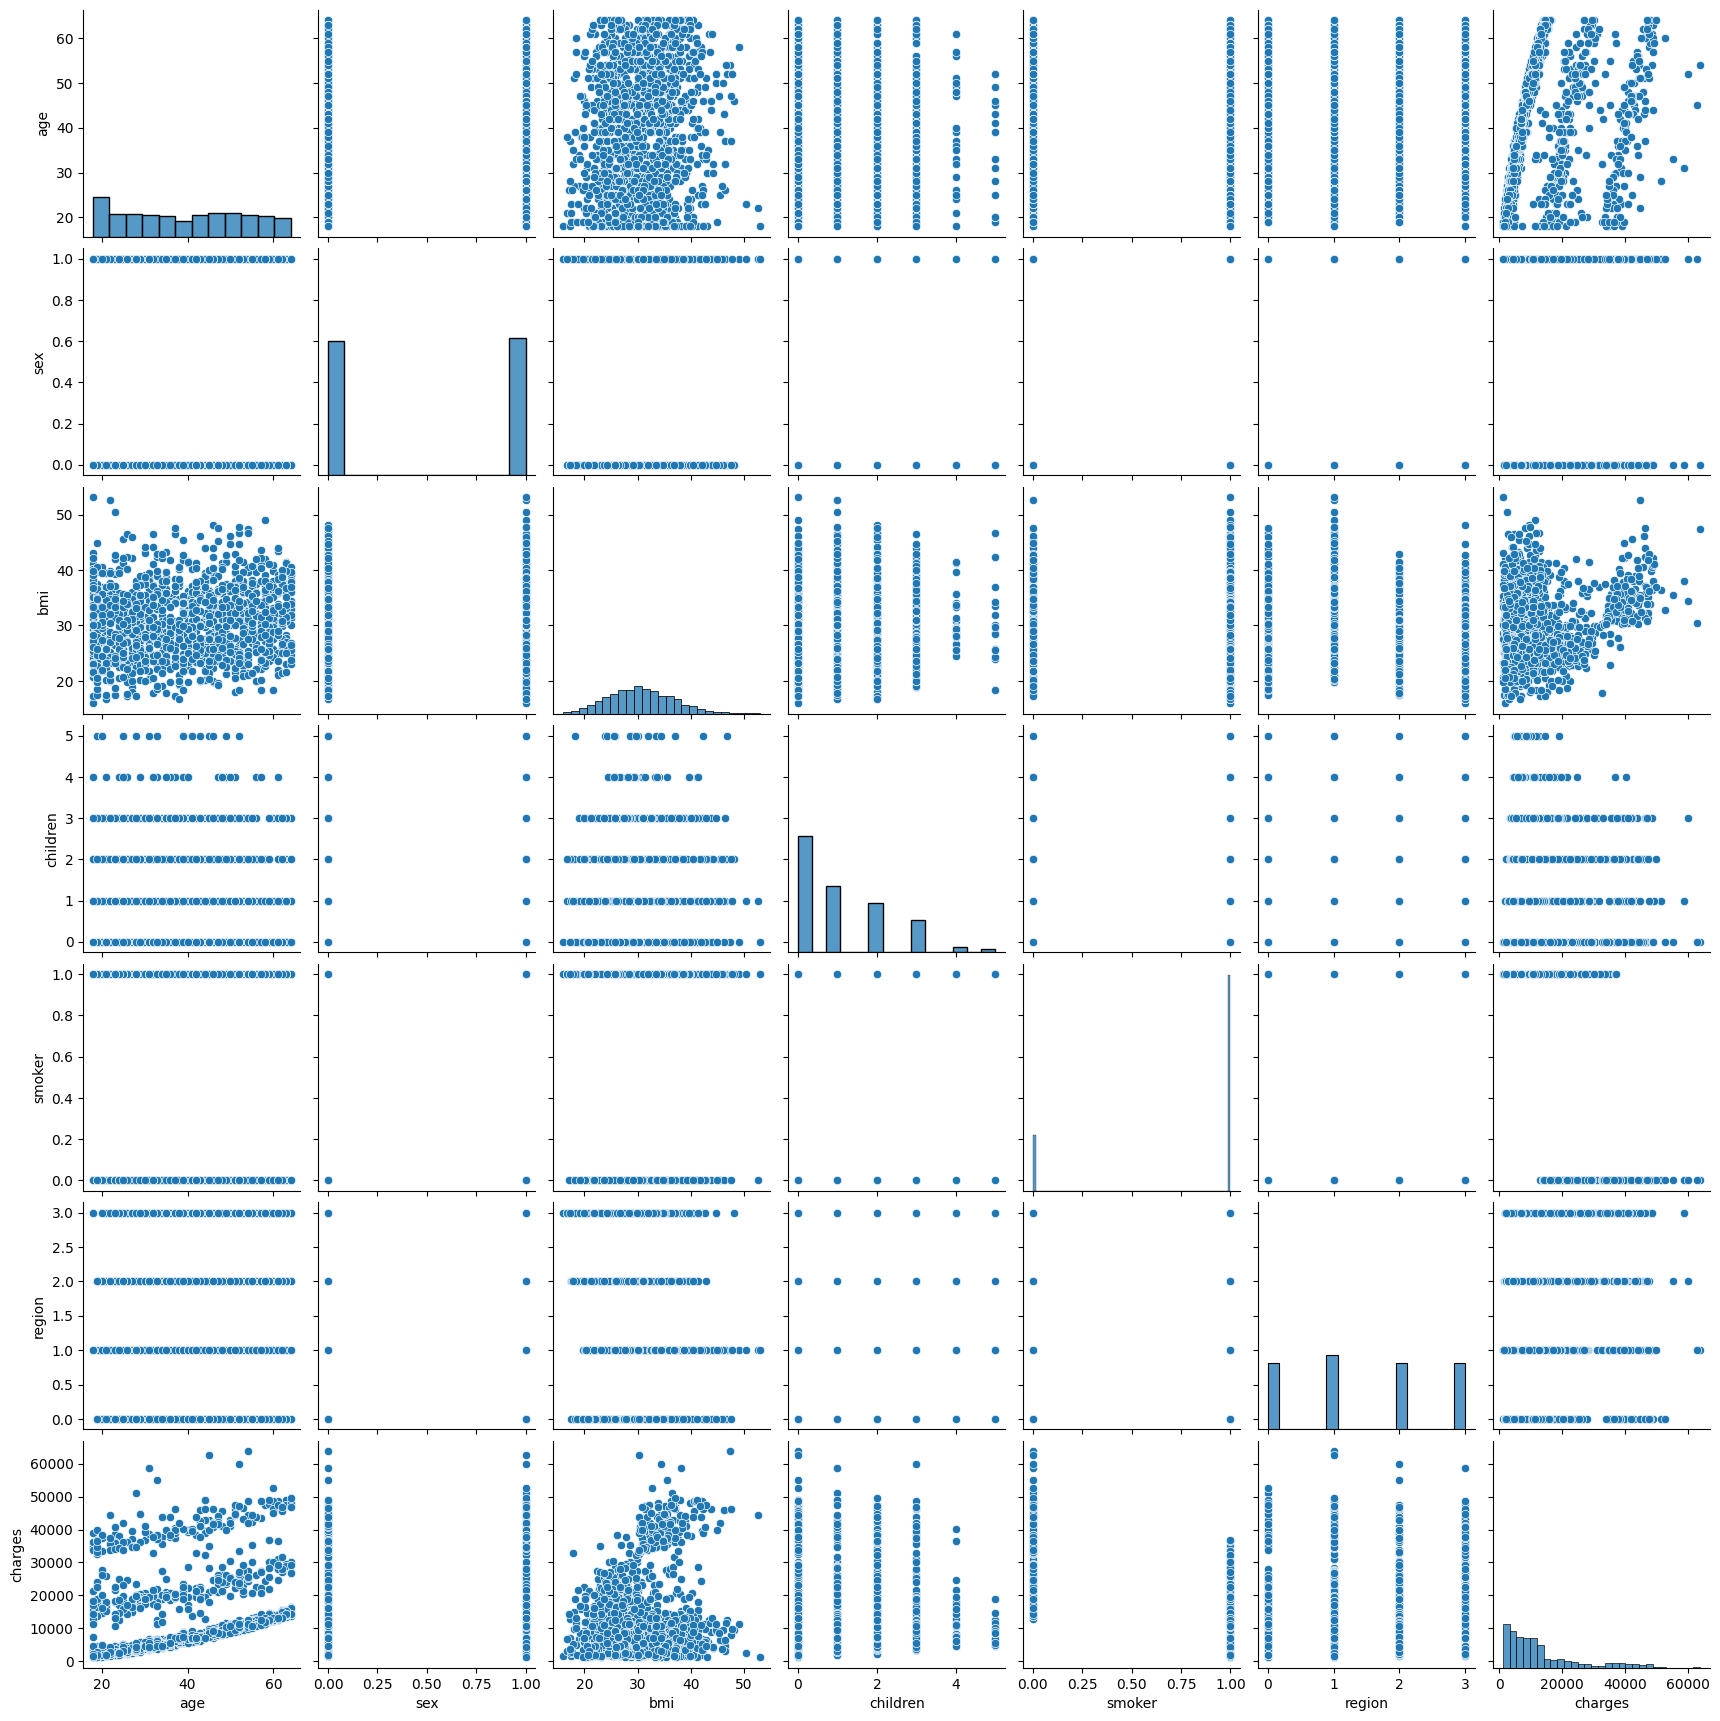

In [12]:
sns.pairplot(data = total_data)

Feature engineering / Ingenieria de características

#### Outlier analysis / Analisis de valores atípicos. 

In [13]:
total_data.describe()

,age,sex,bmi,children,smoker,region,charges
count,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,0.504862,30.663452,1.095737,0.795064,1.483919,13279.121487
std,14.044333,0.500163,6.100468,1.205571,0.403806,1.105208,12110.359656
min,18.000000,0.000000,15.960000,0.000000,0.000000,0.000000,1121.873900
25%,27.000000,0.000000,26.290000,0.000000,1.000000,1.000000,4746.344000
50%,39.000000,1.000000,30.400000,1.000000,1.000000,1.000000,9386.161300
75%,51.000000,1.000000,34.700000,2.000000,1.000000,2.000000,16657.717450
max,64.000000,1.000000,53.130000,5.000000,1.000000,3.000000,63770.428010


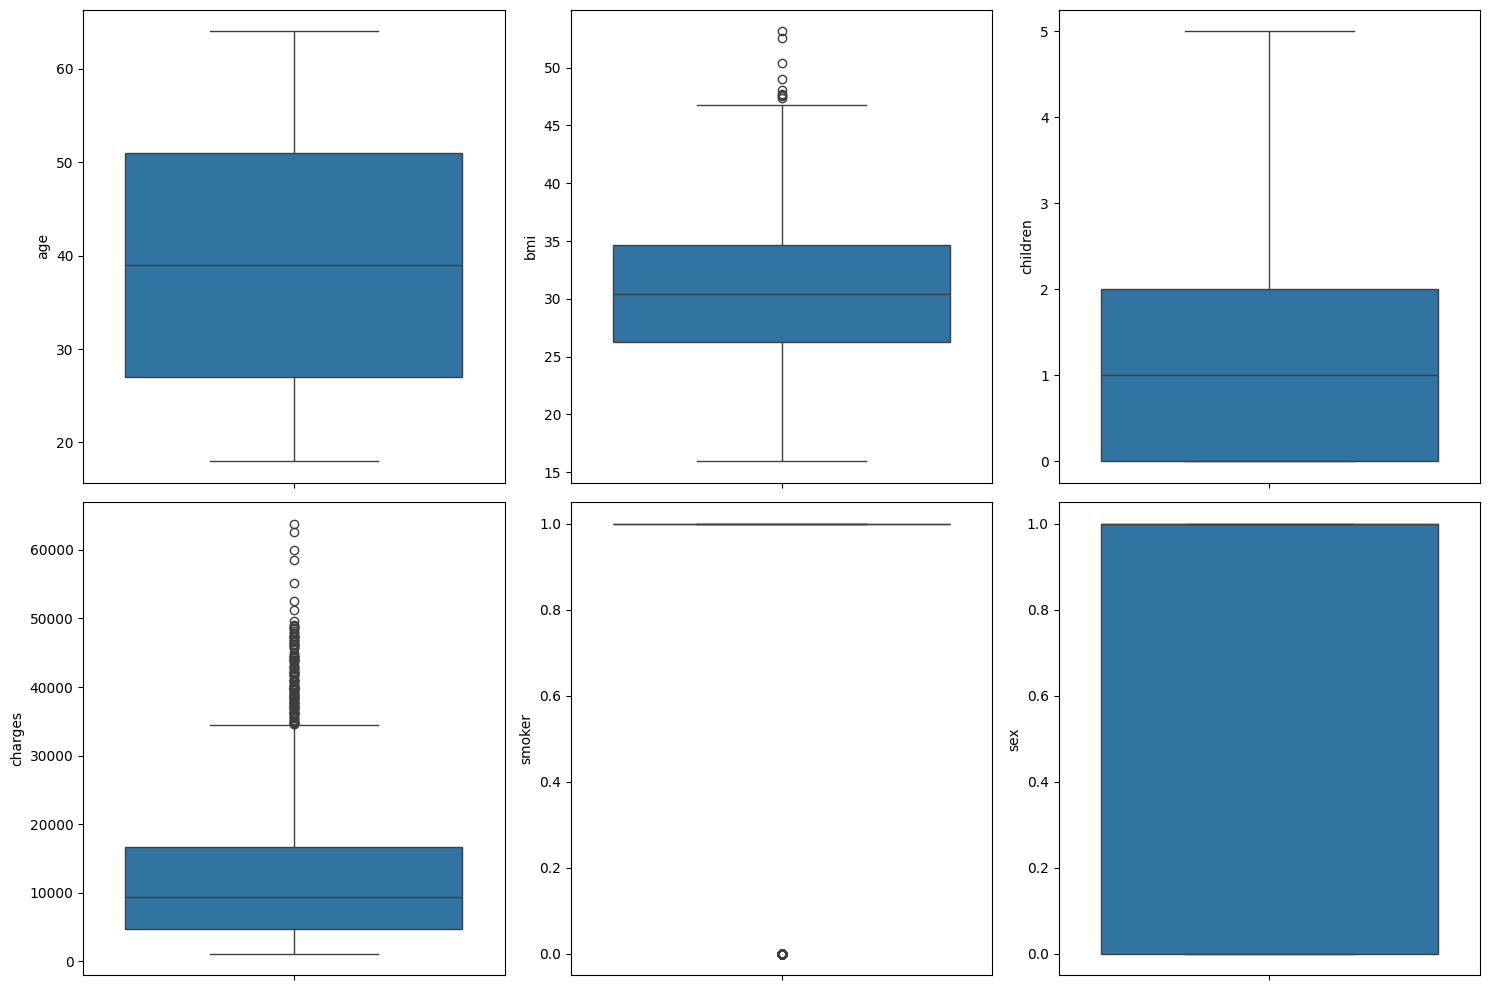

In [14]:
fig, axes = plt.subplots(2, 3, figsize = (15, 10))

sns.boxplot(ax = axes[0, 0], data = total_data, y = "age")
sns.boxplot(ax = axes[0, 1], data = total_data, y = "bmi")
sns.boxplot(ax = axes[0, 2], data = total_data, y = "children")
sns.boxplot(ax = axes[1, 0], data = total_data, y = "charges")
sns.boxplot(ax = axes[1, 1], data = total_data, y = "smoker")
sns.boxplot(ax = axes[1, 2], data = total_data, y = "sex")

plt.tight_layout()

plt.show()

##### Outlier detection for `charges` / Valores atípicos para 'charges'

In [ ]:
# Stats for charges / Estadísticas para charges
charges_stats = total_data["charges"].describe()
charges_stats

count     1337.000000
mean     13279.121487
std      12110.359656
min       1121.873900
25%       4746.344000
50%       9386.161300
75%      16657.717450
max      63770.428010
Name: charges, dtype: float64

In [ ]:
# IQR for charges / Rango intercuartílico para charges

charges_iqr = charges_stats["75%"] - charges_stats["25%"]
upper_limit = charges_stats["75%"] + 1.5 * charges_iqr
lower_limit = charges_stats["25%"] - 1.5 * charges_iqr

print(f"The upper and lower limits for finding outliers are {round(upper_limit, 2)} and {round(lower_limit, 2)}, with an interquartile range of {round(charges_iqr, 2)}")

The upper and lower limits for finding outliers are 34524.78 and -13120.72, with an interquartile range of 11911.37


In [ ]:
# Clean the outliers / Limpiar los outliers

total_data = total_data[total_data["charges"] > 0]

##### Outlier detection for `bmi` / Valores atípicos para 'bmi'

In [18]:
bmi_stats = total_data["bmi"].describe()
bmi_stats

count    1337.000000
mean       30.663452
std         6.100468
min        15.960000
25%        26.290000
50%        30.400000
75%        34.700000
max        53.130000
Name: bmi, dtype: float64

In [ ]:
# IQR for bmi / Rango intercuartílico para bmi
bmi_iqr = bmi_stats["75%"] - bmi_stats["25%"]

upper_limit = bmi_stats["75%"] + 1.5 * bmi_iqr
lower_limit = bmi_stats["25%"] - 1.5 * bmi_iqr

print(f"The upper and lower limits for finding outliers are {round(upper_limit, 2)} and {round(lower_limit, 2)}, with an interquartile range of {round(bmi_iqr, 2)}")

The upper and lower limits for finding outliers are 47.32 and 13.67, with an interquartile range of 8.41


In [ ]:
# Clean the outliers / Limpiar los outliers

total_data = total_data[total_data["bmi"] <= upper_limit]

##### Outlier detection for `age` / Valores atípicos para 'age'

In [ ]:
# Stats for age / Estadísticas para age

age_stats = total_data["age"].describe()
age_stats

count    1328.000000
mean       39.219127
std        14.042170
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

In [ ]:
# IQR for age / Rango intercuartílico para age

age_iqr = age_stats["75%"] - age_stats["25%"]

upper_limit = age_stats["75%"] + 1.5 * age_iqr
lower_limit = age_stats["25%"] - 1.5 * age_iqr

print(f"The upper and lower limits for finding outliers are {round(upper_limit, 2)} and {round(lower_limit, 2)}, with an interquartile range of {round(age_iqr, 2)}")

The upper and lower limits for finding outliers are 87.0 and -9.0, with an interquartile range of 24.0


##### Outlier detection for `children` / Valores atípicos para 'children'

In [ ]:
# Stats for children / Estadísticas para children

children_stats = total_data["children"].describe()
children_stats

count    1328.000000
mean        1.097139
std         1.208008
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max         5.000000
Name: children, dtype: float64

In [ ]:
# IQR for children / Rango intercuartílico para children

children_iqr = children_stats["75%"] - children_stats["25%"]

upper_limit = children_stats["75%"] + 1.5 * children_iqr
lower_limit = children_stats["25%"] - 1.5 * children_iqr

print(f"The upper and lower limits for finding outliers are {round(upper_limit, 2)} and {round(lower_limit, 2)}, with an interquartile range of {round(children_iqr, 2)}")

The upper and lower limits for finding outliers are 5.0 and -3.0, with an interquartile range of 2.0


#### Missing value analysis / Analisis de valores nulos.

In [ ]:
# Count NaN values / Contar valores NaN
total_data.isnull().sum().sort_values(ascending = False)

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

#### Feature scaling / Escalamiento de caracteristicas.

In [26]:
from sklearn.preprocessing import MinMaxScaler

num_variables = ["age", "bmi", "children", "sex", "smoker", "region"]
scaler = MinMaxScaler()
scal_features = scaler.fit_transform(total_data[num_variables])
df_scal = pd.DataFrame(scal_features, index = total_data.index, columns = num_variables)
df_scal["charges"] = total_data["charges"]
df_scal.head()

,age,bmi,children,sex,smoker,region,charges
0,0.021739,0.387788,0.0,0.0,0.0,0.000000,16884.92400
1,0.000000,0.578435,0.2,1.0,1.0,0.333333,1725.55230
2,0.217391,0.553426,0.6,1.0,1.0,0.333333,4449.46200
3,0.326087,0.219065,0.0,1.0,1.0,0.666667,21984.47061
4,0.304348,0.419617,0.0,1.0,1.0,0.666667,3866.85520


### Step 6: Feature selection / Seleccion de caracteristicas.

In [27]:
from sklearn.feature_selection import chi2, SelectKBest
from sklearn.model_selection import train_test_split

X = df_scal.drop("charges", axis = 1)
y = df_scal["charges"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)


selection_model = SelectKBest(chi2, k = 4)
selection_model.fit(X_train, y_train)
ix = selection_model.get_support()
X_train_sel = pd.DataFrame(selection_model.transform(X_train), columns = X_train.columns.values[ix])
X_test_sel = pd.DataFrame(selection_model.transform(X_test), columns = X_test.columns.values[ix])

X_train_sel.head()

ValueError: Unknown label type: (array([ 2134.9015,  8116.68  , 39047.285 , ..., 37829.7242, 11576.13  ,
       11085.5868], shape=(1062,)),)

#### Save the clean and raw data / Guardar la data cruda y limpia. 


In [ ]:
X_train_sel["charges"] = list(y_train)
X_test_sel["charges"] = list(y_test)
X_train_sel.to_csv("../data/processed/clean_train.csv", index = False)
X_test_sel.to_csv("../data/processed/clean_test.csv", index = False)